# Schüler-Lehrer-Relation

## Fragestellung

Wie unterscheiden sich die Schüler-Lehrer-Relationen zwischen öffentlichen
und freien Oberschulen in Sachsen, und wie haben sie sich über die Zeit
entwickelt?

## Schüler-Lehrer-Relation berechnen
Ergebnis:
Bei öffentlichen Schulen trafen steigende Schülerzahlen auf einen leicht rückläufigen Lehrkräftebestand; bei freien Schulen wurde das starke Schülerwachstum von einem noch stärkeren Wachstum der Lehrpersonenzahl übertroffen.

Schüler-Lehrer-Relation: 15,31 → 8,23
2000/01 → 2008/09 bei öffentlichen Oberschulen:
Die Schülerzahl sank mit −63,3 % wesentlich stärker als die Lehrpersonenzahl mit −31,8 %. Dadurch fiel die Schüler-Lehrer-Relation auf ihren historischen Tiefpunkt von 8,23.

2008/09 → 2012/13 bei öffentlichen Oberschulen:
Schüler-Lehrer-Relation: ca. 8,23 → 11,01
Die Entwicklung kehrte sich um: +13,2 % Schüler, gleichzeitig −15,3 % Lehrpersonen. Dadurch stieg die Schüler-Lehrer-Relation um 33,7 % auf rund 11,01.

2012/13 → 2025/26 bei öffentlichen Oberschulen
Schüler-Lehrer-Relation: 11,01 → 14,82
Der Anstieg der Schüler-Lehrer-Relation entsteht hier also durch eine besonders klare Kombination: deutlich mehr Schüler bei gleichzeitig etwas weniger Lehrpersonen.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df_slr = pd.read_csv(
    "../data/cleaned/schueler_lehrer_relation_oberschulen.csv",
    sep=";"
)

display(df_slr.head())
df_slr.info()

,schuljahr,schueler,lehrpersonen,traegerschaft
0,1992/1993,222966,15338,öffentlich
1,1993/1994,216454,14954,öffentlich
2,1994/1995,217118,14985,öffentlich
3,1995/1996,220138,14622,öffentlich
4,1996/1997,222004,14128,öffentlich


<class 'pandas.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   schuljahr      68 non-null     str  
 1   schueler       68 non-null     int64
 2   lehrpersonen   68 non-null     int64
 3   traegerschaft  68 non-null     str  
dtypes: int64(2), str(2)
memory usage: 2.3 KB


### Schüler-Lehrer-Relation berechnen: Schülerzahl/Lehrpersonen
Wichtig: Das ist keine Klassengröße und auch keine Aussage darüber, wie viele Schüler eine Lehrkraft tatsächlich gleichzeitig unterrichtet.

In [6]:
df_slr["schueler_lehrer_relation"] = (
    df_slr["schueler"] / df_slr["lehrpersonen"]
)

df_slr.head()

,schuljahr,schueler,lehrpersonen,traegerschaft,schueler_lehrer_relation
0,1992/1993,222966,15338,öffentlich,14.536837
1,1993/1994,216454,14954,öffentlich,14.474656
2,1994/1995,217118,14985,öffentlich,14.489022
3,1995/1996,220138,14622,öffentlich,15.055259
4,1996/1997,222004,14128,öffentlich,15.713760


Zum Vergleich, beide Träger nebeneinander ausgeben:

In [7]:
vergleich_slr = df_slr.pivot( # hier wird die Pivot-Tabelle erstellt, um die Schüler-Lehrer-Relation nach Schuljahr und Trägerschaft zu vergleichen
    index="schuljahr",
    columns="traegerschaft",
    values="schueler_lehrer_relation"
)

vergleich_slr

traegerschaft,frei,öffentlich
schuljahr,,
1992/1993,20.250000,14.536837
1993/1994,15.694444,14.474656
1994/1995,22.625000,14.489022
1995/1996,19.416667,15.055259
1996/1997,14.046512,15.713760
1997/1998,13.175439,15.419804
1998/1999,14.111111,15.291244
1999/2000,13.696203,15.288964
2000/2001,14.447059,15.310161


## Erste Visualisierung als Liniendiagramm, da Darstellung über eine Zeitachse

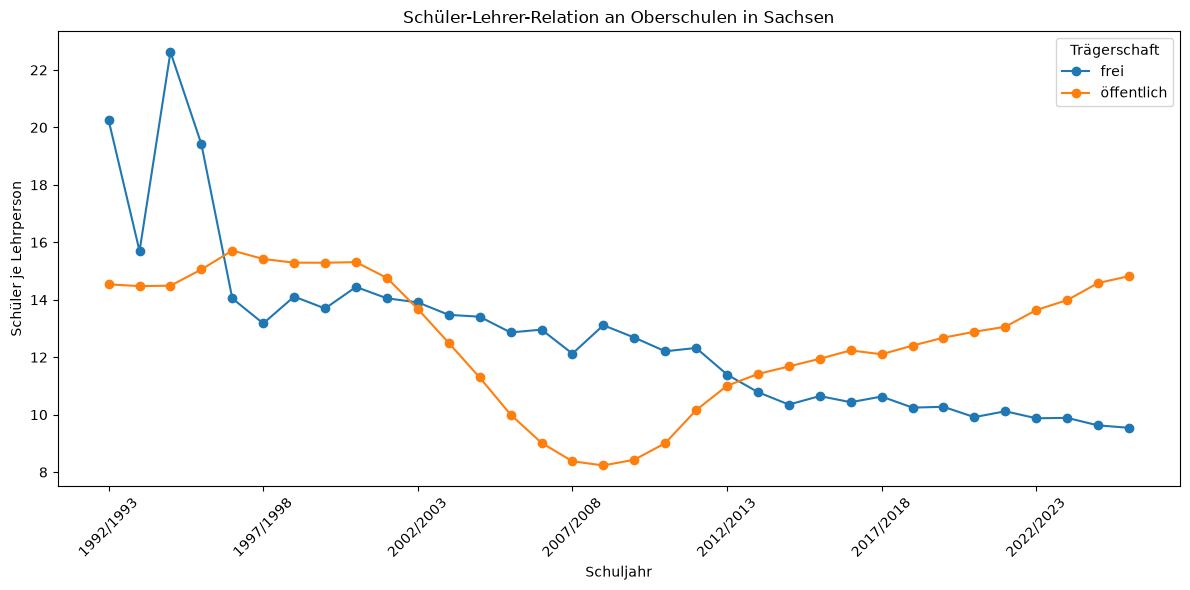

In [8]:
ax = vergleich_slr.plot(
    figsize=(12, 6),
    marker="o"
)

ax.set_title("Schüler-Lehrer-Relation an Oberschulen in Sachsen")
ax.set_xlabel("Schuljahr")
ax.set_ylabel("Schüler je Lehrperson")
ax.legend(title="Trägerschaft")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Differenz berechnen
Ergebnis deuten: 
negativer Vorzeichen--> freie Schulen haben mehr Schüler je Lehrpersonal
positives Vorzeichen--> öffentliche Schulen haben mehr Schüler je Lehrperson
nahe 0: ähnliche Relation

In [9]:
vergleich_slr["differenz"] = (
    vergleich_slr["öffentlich"] - vergleich_slr["frei"]
)

vergleich_slr[["öffentlich", "frei", "differenz"]]

traegerschaft,öffentlich,frei,differenz
schuljahr,,,
1992/1993,14.536837,20.250000,-5.713163
1993/1994,14.474656,15.694444,-1.219789
1994/1995,14.489022,22.625000,-8.135978
1995/1996,15.055259,19.416667,-4.361407
1996/1997,15.713760,14.046512,1.667248
1997/1998,15.419804,13.175439,2.244365
1998/1999,15.291244,14.111111,1.180133
1999/2000,15.288964,13.696203,1.592761
2000/2001,15.310161,14.447059,0.863102


### Wie hat sich das Schüler-Lehrer-Verhältnis seit dem dauerhaften Wechsel 2013/14 geändert:

In [10]:
start = vergleich_slr.loc["2013/2014", ["öffentlich", "frei"]]
ende = vergleich_slr.loc["2025/2026", ["öffentlich", "frei"]]

entwicklung = pd.DataFrame({
    "2013/2014": start,
    "2025/2026": ende,
    "veraenderung_absolut": ende - start,
    "veraenderung_prozent": (ende / start - 1) * 100
})

entwicklung.round(2)

,2013/2014,2025/2026,veraenderung_absolut,veraenderung_prozent
traegerschaft,,,,
öffentlich,11.42,14.82,3.41,29.85
frei,10.78,9.54,-1.24,-11.51


Eine niedrigere Relation bedeutet zunächst nur weniger Schüler je erfasster Lehrperson. Daraus dürfen wir noch nicht unmittelbar auf kleinere Klassen, höhere Unterrichtsqualität oder eine geringere tatsächliche Arbeitsbelastung schließen.

### Extremwerte bestimmen

In [11]:
for traeger in ["öffentlich", "frei"]:
    niedrigstes_jahr = vergleich_slr[traeger].idxmin()
    hoechstes_jahr = vergleich_slr[traeger].idxmax()

    print(f"{traeger}:")
    print(
        f"  Minimum: {vergleich_slr.loc[niedrigstes_jahr, traeger]:.2f} "
        f"({niedrigstes_jahr})"
    )
    print(
        f"  Maximum: {vergleich_slr.loc[hoechstes_jahr, traeger]:.2f} "
        f"({hoechstes_jahr})"
    )

öffentlich:
  Minimum: 8.23 (2008/2009)
  Maximum: 15.71 (1996/1997)
frei:
  Minimum: 9.54 (2025/2026)
  Maximum: 22.62 (1994/1995)


Woran liegt es, dass der Quotient sich verändert hat un dzum Beispiel es zu einem Tiefpunkt von 8,23 gekommen ist. Liegt es an der steigenden Lehrerzahl, an der sinkenden Schülerzahl oder an beidem zusammen?

# Öffentliche Oberschulen untersuchen

In [12]:
oeffentlich_phase = df_slr[
    (df_slr["traegerschaft"] == "öffentlich")
    & (df_slr["schuljahr"].between("2000/2001", "2012/2013"))
].copy()

oeffentlich_phase[
    ["schuljahr", "schueler", "lehrpersonen", "schueler_lehrer_relation"]
]

,schuljahr,schueler,lehrpersonen,schueler_lehrer_relation
8,2000/2001,207024,13522,15.310161
9,2001/2002,194704,13190,14.761486
10,2002/2003,174977,12793,13.677558
11,2003/2004,153734,12300,12.498699
12,2004/2005,132333,11717,11.294103
13,2005/2006,110302,11026,10.003809
14,2006/2007,91658,10163,9.018794
15,2007/2008,79609,9503,8.377249
16,2008/2009,75911,9221,8.232404
17,2009/2010,75644,8972,8.431119


In [13]:
start = oeffentlich_phase.loc[
    oeffentlich_phase["schuljahr"] == "2000/2001"
].iloc[0]

tiefpunkt = oeffentlich_phase.loc[
    oeffentlich_phase["schuljahr"] == "2008/2009"
].iloc[0]

veraenderung = pd.DataFrame({
    "2000/2001": [start["schueler"], start["lehrpersonen"]],
    "2008/2009": [tiefpunkt["schueler"], tiefpunkt["lehrpersonen"]],
}, index=["Schüler", "Lehrpersonen"])

veraenderung["Veränderung absolut"] = (
    veraenderung["2008/2009"] - veraenderung["2000/2001"]
)

veraenderung["Veränderung Prozent"] = (
    (veraenderung["2008/2009"] / veraenderung["2000/2001"] - 1) * 100
)

veraenderung.round(1)

,2000/2001,2008/2009,Veränderung absolut,Veränderung Prozent
Schüler,207024,75911,-131113,-63.3
Lehrpersonen,13522,9221,-4301,-31.8


Die Schülerzahl schrumpfte damit prozentual ungefähr doppelt so stark wie die Lehrpersonenzahl. Genau dadurch fiel die Schüler-Lehrer-Relation von 15,31 auf 8,23 Schüler je Lehrperson.

Ab 2008/09 steigen die Schülerzahlen wieder (75.911 → 85.965 bis 2012/13), während die Lehrpersonenzahl gleichzeitig weiter sinkt (9.221 → 7.811). --> Wendepunkt

Betrachtung der Zahlen, nach dem Wendepunkt:

In [14]:
start = oeffentlich_phase.loc[
    oeffentlich_phase["schuljahr"] == "2008/2009"
].iloc[0]

ende = oeffentlich_phase.loc[
    oeffentlich_phase["schuljahr"] == "2012/2013"
].iloc[0]

gegenbewegung = pd.DataFrame({
    "2008/2009": [
        start["schueler"],
        start["lehrpersonen"],
        start["schueler_lehrer_relation"],
    ],
    "2012/2013": [
        ende["schueler"],
        ende["lehrpersonen"],
        ende["schueler_lehrer_relation"],
    ],
}, index=["Schüler", "Lehrpersonen", "Schüler-Lehrer-Relation"])

gegenbewegung["Veränderung absolut"] = (
    gegenbewegung["2012/2013"] - gegenbewegung["2008/2009"]
)

gegenbewegung["Veränderung Prozent"] = (
    (gegenbewegung["2012/2013"] / gegenbewegung["2008/2009"] - 1) * 100
)

gegenbewegung.round(1)

,2008/2009,2012/2013,Veränderung absolut,Veränderung Prozent
Schüler,75911.0,85965.0,10054.0,13.2
Lehrpersonen,9221.0,7811.0,-1410.0,-15.3
Schüler-Lehrer-Relation,8.2,11.0,2.8,33.7


Entwicklung ab 1012/13 untersuchen:

In [15]:
oeffentlich_aktuell = df_slr[
    (df_slr["traegerschaft"] == "öffentlich")
    & (df_slr["schuljahr"].between("2012/2013", "2025/2026"))
].copy()

oeffentlich_aktuell[
    ["schuljahr", "schueler", "lehrpersonen", "schueler_lehrer_relation"]
]

,schuljahr,schueler,lehrpersonen,schueler_lehrer_relation
20,2012/2013,85965,7811,11.005633
21,2013/2014,88244,7730,11.415783
22,2014/2015,90417,7742,11.678765
23,2015/2016,93434,7821,11.946554
48,2016/2017,95946,7840,12.238010
50,2017/2018,96663,7987,12.102542
52,2018/2019,97982,7899,12.404355
54,2019/2020,99367,7836,12.680832
56,2020/2021,100668,7812,12.886329
58,2021/2022,101633,7782,13.060010


In [16]:
start = oeffentlich_aktuell.loc[
    oeffentlich_aktuell["schuljahr"] == "2012/2013"
].iloc[0]

ende = oeffentlich_aktuell.loc[
    oeffentlich_aktuell["schuljahr"] == "2025/2026"
].iloc[0]

entwicklung_aktuell = pd.DataFrame({
    "2012/2013": [
        start["schueler"],
        start["lehrpersonen"],
        start["schueler_lehrer_relation"],
    ],
    "2025/2026": [
        ende["schueler"],
        ende["lehrpersonen"],
        ende["schueler_lehrer_relation"],
    ],
}, index=["Schüler", "Lehrpersonen", "Schüler-Lehrer-Relation"])

entwicklung_aktuell["Veränderung absolut"] = (
    entwicklung_aktuell["2025/2026"]
    - entwicklung_aktuell["2012/2013"]
)

entwicklung_aktuell["Veränderung Prozent"] = (
    (
        entwicklung_aktuell["2025/2026"]
        / entwicklung_aktuell["2012/2013"]
        - 1
    )
    * 100
)

entwicklung_aktuell.round(1)

,2012/2013,2025/2026,Veränderung absolut,Veränderung Prozent
Schüler,85965.0,108596.0,22631.0,26.3
Lehrpersonen,7811.0,7326.0,-485.0,-6.2
Schüler-Lehrer-Relation,11.0,14.8,3.8,34.7


# Freie Oberschulen untersuchen

Ist bei freien Oberschulen die Lehrpersonenzahl stärker gewachsen als die Schülerzahl?

In [17]:
frei_aktuell = df_slr[
    (df_slr["traegerschaft"] == "frei")
    & (df_slr["schuljahr"].between("2013/2014", "2025/2026"))
].copy()

frei_aktuell[
    ["schuljahr", "schueler", "lehrpersonen", "schueler_lehrer_relation"]
]

,schuljahr,schueler,lehrpersonen,schueler_lehrer_relation
45,2013/2014,9242,857,10.784131
46,2014/2015,9793,946,10.352008
47,2015/2016,10328,970,10.647423
49,2016/2017,11029,1057,10.434248
51,2017/2018,11747,1105,10.630769
53,2018/2019,12571,1227,10.245314
55,2019/2020,13459,1310,10.274046
57,2020/2021,14266,1439,9.913829
59,2021/2022,15259,1508,10.118700
61,2022/2023,15948,1615,9.874923


In [18]:
start = frei_aktuell.loc[
    frei_aktuell["schuljahr"] == "2013/2014"
].iloc[0]

ende = frei_aktuell.loc[
    frei_aktuell["schuljahr"] == "2025/2026"
].iloc[0]

entwicklung_frei = pd.DataFrame({
    "2013/2014": [
        start["schueler"],
        start["lehrpersonen"],
        start["schueler_lehrer_relation"],
    ],
    "2025/2026": [
        ende["schueler"],
        ende["lehrpersonen"],
        ende["schueler_lehrer_relation"],
    ],
}, index=["Schüler", "Lehrpersonen", "Schüler-Lehrer-Relation"])

entwicklung_frei["Veränderung absolut"] = (
    entwicklung_frei["2025/2026"]
    - entwicklung_frei["2013/2014"]
)

entwicklung_frei["Veränderung Prozent"] = (
    (
        entwicklung_frei["2025/2026"]
        / entwicklung_frei["2013/2014"]
        - 1
    )
    * 100
)

entwicklung_frei.round(1)

,2013/2014,2025/2026,Veränderung absolut,Veränderung Prozent
Schüler,9242.0,17864.0,8622.0,93.3
Lehrpersonen,857.0,1872.0,1015.0,118.4
Schüler-Lehrer-Relation,10.8,9.5,-1.2,-11.5


### Vergleichstabelle:

In [19]:
vergleich_entwicklung = (
    df_slr[
        df_slr["schuljahr"].isin(["2013/2014", "2025/2026"])
    ]
    .pivot(
        index="traegerschaft",
        columns="schuljahr",
        values=["schueler", "lehrpersonen", "schueler_lehrer_relation"]
    )
)

vergleich_entwicklung

schueler           lehrpersonen            \
schuljahr     2013/2014 2025/2026    2013/2014 2025/2026   
traegerschaft                                              
frei             9242.0   17864.0        857.0    1872.0   
öffentlich      88244.0  108596.0       7730.0    7326.0   

              schueler_lehrer_relation             
schuljahr                    2013/2014  2025/2026  
traegerschaft                                      
frei                         10.784131   9.542735  
öffentlich                   11.415783  14.823369

Gegenüberstellung der prozentualen Veränderung für den Zeitraum 2013/14–2025/26

In [21]:
print("Zeitraum 2013/14–2025/26")
vergleich_prozent = pd.DataFrame({
    "Schüler": (
        vergleich_entwicklung[("schueler", "2025/2026")]
        / vergleich_entwicklung[("schueler", "2013/2014")]
        - 1
    ) * 100,

    "Lehrpersonen": (
        vergleich_entwicklung[("lehrpersonen", "2025/2026")]
        / vergleich_entwicklung[("lehrpersonen", "2013/2014")]
        - 1
    ) * 100,

    "Schüler-Lehrer-Relation": (
        vergleich_entwicklung[("schueler_lehrer_relation", "2025/2026")]
        / vergleich_entwicklung[("schueler_lehrer_relation", "2013/2014")]
        - 1
    ) * 100,
})

vergleich_prozent.round(1)

Zeitraum 2013/14–2025/26


,Schüler,Lehrpersonen,Schüler-Lehrer-Relation
traegerschaft,,,
frei,93.3,118.4,-11.5
öffentlich,23.1,-5.2,29.8


Bei freien Oberschulen stieg die Schülerzahl wesentlich stärker um 93,3 %. Gleichzeitig nahm die Zahl der Lehrpersonen mit 118,4 % noch stärker zu.

Bei öffentlichen Oberschulen stieg die Schülerzahl um 23,1 %, während die Zahl der Lehrpersonen um 5,2 % zurückging.